 # A/B Testing marketing — quelle campagne convertit le mieux ?
      

## I- Cadrage expérimental

**Question business :**
Montrer la vraie publicité (groupe `ad`) fait-il convertir davantage
les utilisateurs que montrer une annonce neutre de service public
(groupe `psa`) ?

**Métrique primaire :**
Le taux de conversion de chaque groupe, c'est-à-dire la proportion
d'utilisateurs ayant converti (`converted = True`). Calculé comme la
moyenne de la colonne `converted` (où True = 1, False = 0).

**H₀ (hypothèse nulle) :**
Le vrai taux de conversion du groupe `ad` est égal à celui du groupe
`psa`. La publicité n'a aucun effet ; tout écart observé n'est dû
qu'au hasard de l'échantillonnage.

**H₁ (hypothèse alternative) :**
Les deux vrais taux de conversion ne sont pas égaux : il existe une
différence réelle entre `ad` et `psa`.

**Seuil de décision α :**
α = 0,05. Règle : si la p-value < 0,05, on rejette H₀ et on conclut
que la différence est statistiquement significative ; si la
p-value ≥ 0,05, on ne rejette pas H₀ (preuves insuffisantes).

## II -Validation des données
 Avant tout test, vérifions que l'expérience est fiable : équilibre des groupes, doublons.

In [5]:
import pandas as pd
df = pd.read_csv("data/marketing_AB.csv", index_col=0)

print(df.shape)

df.head()

(588101, 6)


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


 ### Contrôle 1 - Répartition des groupes (SRM)

In [12]:
df.groupby("test group").count()

,user id,converted,total ads,most ads day,most ads hour
test group,,,,,
ad,564577,564577,564577,564577,564577
psa,23524,23524,23524,23524,23524


In [15]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [19]:
df["test group"].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

**Répartition des groupes :** ad = 96,0 %, psa = 4,0 % (déséquilibre voulu).

**Contrôle SRM (Sample Ratio Mismatch) :**
Le ratio observé est de 96,00 % / 4,00 %, d'une netteté remarquable.
Un dysfonctionnement de la mécanique d'assignation (bug de
randomisation, filtre supprimant des utilisateurs d'un groupe)
produirait typiquement un ratio bancal et non rond ; la propreté de
ce 96/4 pointe donc vers une répartition décidée volontairement par
l'équipe, et non vers une anomalie. → Pas de drapeau rouge SRM.

**Caveat :** le document de conception de l'expérience n'étant pas
disponible, la cible d'assignation visée n'est pas connue
officiellement. Un test SRM formel (comparaison du ratio observé à
une cible fixée à l'avance) ne peut donc pas être mené de façon
rigoureuse. Dans un contexte réel, on confirmerait la répartition
cible auprès de l'équipe ayant conçu l'expérience avant de valider
définitivement ce point.

### Contrôle 2 - Doublons d'utilisateurs

In [22]:
df["user id"].duplicated().sum()

np.int64(0)

**Contrôle des doublons :** 0 user id en double.
Chaque ligne correspond à un utilisateur unique ; aucun utilisateur
n'appartient simultanément aux deux groupes. → Données valides pour
la comparaison.

## III - Test statistique

In [25]:
# Succès (nombre de conversions) par groupe
conversions = df.groupby("test group")["converted"].sum()

# Taille de chaque groupe
tailles = df.groupby("test group")["converted"].count()

print(conversions)
print(tailles)

test group
ad     14423
psa      420
Name: converted, dtype: int64
test group
ad     564577
psa     23524
Name: converted, dtype: int64


In [28]:
from statsmodels.stats.proportion import proportions_ztest

# Ordre : [ad, psa] pour les deux tableaux
count = [14423, 420]
nobs  = [564577, 23524]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Statistique z : {z_stat:.4f}")
print(f"p-value       : {p_value:.15f}")

Statistique z : 7.3701
p-value       : 0.000000000000171


**Test choisi :** test z de comparaison de deux proportions
(*two-proportion z-test*, `statsmodels.stats.proportion.proportions_ztest`).
Justification : la métrique `converted` est binaire (oui/non), on
compare donc deux proportions (taux de conversion), et non deux
moyennes. Test bilatéral, cohérent avec H₁ (« les deux taux ne sont
pas égaux »).

**Ingrédients :**
- ad  : 14 423 conversions / 564 577 → 2,55 %
- psa :    420 conversions /  23 524 → 1,79 %

**Résultat :** statistique z = 7,37 ; p-value ≈ 1,7e-13
(très inférieure à 0,000001).

**Décision statistique :** p-value ≪ α = 0,05 → on rejette H₀.
La différence entre les deux taux de conversion est
statistiquement significative : elle est bien trop marquée, vu la
taille des groupes, pour être un accident du hasard.

**Significativité pratique (lift) :** l'écart absolu (0,76 point)
paraît faible, mais l'écart relatif est déterminant :
2,55 % / 1,79 % ≈ 1,42, soit +42 % de conversions. À nombre égal
d'utilisateurs exposés, la vraie publicité convertit 42 % de plus
que l'annonce neutre - un effet largement significatif pour
l'entreprise.

**Conclusion :** la publicité surpasse l'annonce neutre de façon à la
fois statistiquement et pratiquement significative. Recommandation :
déployer la vraie campagne publicitaire.

## IV - Segmentation 

### Segmentation par jour de la semaine

In [30]:
# On stocke le tableau pour le réutiliser
taux_jour = df.groupby(["most ads day", "test group"])["converted"].mean().unstack()

# Écart absolu et lift relatif, jour par jour
taux_jour["ecart_absolu"] = taux_jour["ad"] - taux_jour["psa"]
taux_jour["lift_relatif"] = taux_jour["ad"] / taux_jour["psa"]

# Trié du jour où la pub apporte le plus au jour où elle apporte le moins
taux_jour.sort_values("lift_relatif", ascending=False)

test group,ad,psa,ecart_absolu,lift_relatif
most ads day,,,,
Tuesday,0.030440,0.014448,0.015992,2.106909
Wednesday,0.025356,0.015759,0.009597,1.608945
Saturday,0.021307,0.013996,0.007311,1.522354
Monday,0.033241,0.022559,0.010683,1.473553
Friday,0.022465,0.016303,0.006162,1.377971
Sunday,0.024620,0.020595,0.004025,1.195430
Thursday,0.021637,0.020230,0.001407,1.069532


In [31]:
df.groupby(["most ads day", "test group"]).size().unstack()

test group,ad,psa
most ads day,,
Friday,88805,3803
Monday,83571,3502
Saturday,78802,2858
Sunday,82332,3059
Thursday,79077,3905
Tuesday,74572,2907
Wednesday,77418,3490


In [32]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05
jours = taux_jour.index          # les 7 jours
n_tests = len(jours)             # = 7
alpha_corrige = alpha / n_tests  # Bonferroni

print(f"Seuil corrigé (Bonferroni) : {alpha_corrige:.4f}\n")

for jour in jours:
    sous_groupe = df[df["most ads day"] == jour]

    # succès et tailles pour ce jour, ordre [ad, psa]
    count = [
        sous_groupe[sous_groupe["test group"] == "ad"]["converted"].sum(),
        sous_groupe[sous_groupe["test group"] == "psa"]["converted"].sum(),
    ]
    nobs = [
        (sous_groupe["test group"] == "ad").sum(),
        (sous_groupe["test group"] == "psa").sum(),
    ]

    z, p = proportions_ztest(count, nobs)
    verdict = "significatif" if p < alpha_corrige else "NON significatif"
    print(f"{jour:10s} | p-value = {p:.5f} | {verdict}")

Seuil corrigé (Bonferroni) : 0.0071

Friday     | p-value = 0.01157 | NON significatif
Monday     | p-value = 0.00051 | significatif
Saturday   | p-value = 0.00748 | NON significatif
Sunday     | p-value = 0.15719 | NON significatif
Thursday   | p-value = 0.55475 | NON significatif
Tuesday    | p-value = 0.00000 | significatif
Wednesday  | p-value = 0.00038 | significatif


**Démarche :** on décompose le résultat global (+42 % de lift) jour
par jour, en comparant le taux de conversion ad vs psa pour chaque
`most ads day`. On classe les jours par **lift relatif** (ad / psa)
plutôt que par taux brut : ce qui compte pour le business n'est pas
le jour où la pub convertit le plus dans l'absolu, mais celui où elle
**apporte** le plus par rapport à ne rien faire (annonce neutre).

**Piège traité - comparaisons multiples :** tester les 7 jours puis
retenir le plus impressionnant gonfle le risque de faux positif
(≈ 30 % de chance qu'au moins un test crie « significatif » par
hasard, au lieu de 5 %). Correction de **Bonferroni** : seuil durci à
α / 7 ≈ 0,0071 au lieu de 0,05. On a aussi vérifié les effectifs par
jour, la plus petite case (psa samedi ≈ 2 858) reste suffisante, les
tailles ne sont donc pas un problème.

**Résultats (après correction, seuil 0,0071) :**
- Significatifs : mardi (p ≈ 0, lift +111 %), mercredi, lundi,
  samedi (0,0075, de justesse).
- Non significatifs : vendredi, dimanche, jeudi.
- Cas notable - **vendredi** : p = 0,0116. Significatif sous l'ancien
  seuil 0,05, il **échoue** sous le seuil corrigé. C'est précisément
  le faux positif que Bonferroni est là pour éliminer.

**Insight business :** l'effet de la pub est solide et fiable en
début/milieu de semaine (mardi, mercredi, lundi) et le samedi ; rien
ne prouve qu'elle apporte quoi que ce soit le jeudi ni le dimanche.
Recommandation : concentrer le budget sur le mardi (lift +111 %) et
les autres jours significatifs ; réévaluer, voire couper, la dépense
du jeudi et du dimanche.

### Segmentation par heure 

In [37]:
taux_heure = df.groupby(["most ads hour", "test group"])["converted"].mean().unstack()
taux_heure["lift_relatif"] = taux_heure["ad"] / taux_heure["psa"]

# effectifs, pour garder l'œil sur les petites cases
effectifs_heure = df.groupby(["most ads hour", "test group"]).size().unstack()

taux_heure.sort_values("lift_relatif", ascending=False)

test group,ad,psa,lift_relatif
most ads hour,,,
0,0.019213,0.000000,inf
1,0.013434,0.000000,inf
2,0.007570,0.000000,inf
4,0.015850,0.000000,inf
6,0.023174,0.000000,inf
5,0.021563,0.000000,inf
7,0.018482,0.008439,2.190175
8,0.019861,0.010622,1.869763
9,0.019529,0.010815,1.805671


In [38]:
print(effectifs_heure)

test group        ad   psa
most ads hour             
0               5309   227
1               4615   187
2               5152   181
3               2590    89
4                694    28
5                742    23
6               1985    83
7               6168   237
8              16968   659
9              29802  1202
10             37454  1485
11             44149  2061
12             45238  2060
13             45485  2170
14             43779  1869
15             42855  1828
16             35963  1604
17             33605  1383
18             31052  1271
19             29169  1183
20             27846  1077
21             28895  1081
22             25515   917
23             19547   619


In [39]:
from statsmodels.stats.proportion import proportions_ztest

SEUIL_MIN = 100  # minimum de psa pour qu'une heure soit testable

heures_valides = effectifs_heure[effectifs_heure["psa"] >= SEUIL_MIN].index
n_tests = len(heures_valides)
alpha_corrige = 0.05 / n_tests

print(f"Heures testées : {n_tests} | seuil Bonferroni : {alpha_corrige:.4f}\n")

resultats = []
for h in heures_valides:
    sg = df[df["most ads hour"] == h]
    count = [sg[sg["test group"]=="ad"]["converted"].sum(),
             sg[sg["test group"]=="psa"]["converted"].sum()]
    nobs  = [(sg["test group"]=="ad").sum(),
             (sg["test group"]=="psa").sum()]
    z, p = proportions_ztest(count, nobs)
    resultats.append((h, p, "significatif" if p < alpha_corrige else "non"))

for h, p, v in sorted(resultats, key=lambda x: x[1]):
    print(f"{h:2d}h | p = {p:.5f} | {v}")

Heures testées : 20 | seuil Bonferroni : 0.0025

14h | p = 0.00132 | significatif
13h | p = 0.01293 | non
20h | p = 0.01675 | non
11h | p = 0.01695 | non
10h | p = 0.02922 | non
 9h | p = 0.03086 | non
 0h | p = 0.03504 | non
12h | p = 0.03747 | non
22h | p = 0.05955 | non
17h | p = 0.06797 | non
 8h | p = 0.09253 | non
23h | p = 0.09823 | non
 1h | p = 0.11064 | non
21h | p = 0.17924 | non
 2h | p = 0.24006 | non
15h | p = 0.24793 | non
 7h | p = 0.25519 | non
16h | p = 0.51961 | non
18h | p = 0.62343 | non
19h | p = 0.63128 | non


**Problème rencontré :** en découpant en ~24 heures, les sous-groupes
deviennent trop petits (psa à 4h = 23 personnes ; plusieurs heures
creuses avec 0 conversion → lift = inf). Un taux calculé sur si peu de
monde n'est pas fiable.

**Traitement :** filtrage à un seuil minimum (≥ 100 psa par heure) →
20 heures testables. Bonferroni recalculé sur 20 tests → seuil 0,0025.

**Résultat :** une seule heure significative, 14h (p = 0,0013). 13h
(p = 0,013) aurait passé le seuil naïf de 0,05 mais échoue après
correction - faux positif évité.

**Leçon :** le double étau (Bonferroni plus sévère + cases moins
peuplées, donc tests moins puissants) rend le grain horaire trop fin
pour ce jeu de données. Le grain **jour** est le bon niveau
d'analyse ; descendre à l'heure fait perdre fiabilité et puissance
sans gain d'insight. Savoir choisir la granularité fait partie du
métier.

## V - Visualisations

### Le résultat principal (taux par groupe)

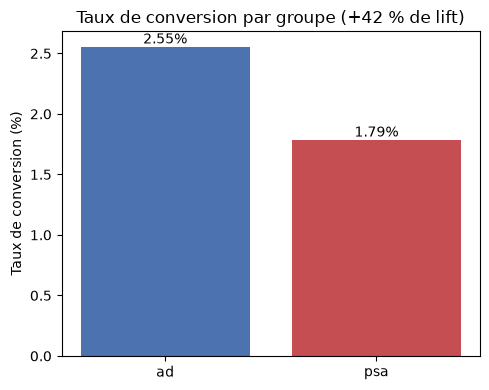

In [40]:
import matplotlib.pyplot as plt

taux = df.groupby("test group")["converted"].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(taux.index, taux.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Taux de conversion (%)")
ax.set_title("Taux de conversion par groupe (+42 % de lift)")
ax.bar_label(bars, fmt="%.2f%%")
plt.tight_layout()
plt.savefig("conversion_par_groupe.png", dpi=120)
plt.show()

### L'insight de segmentation (lift par jour)

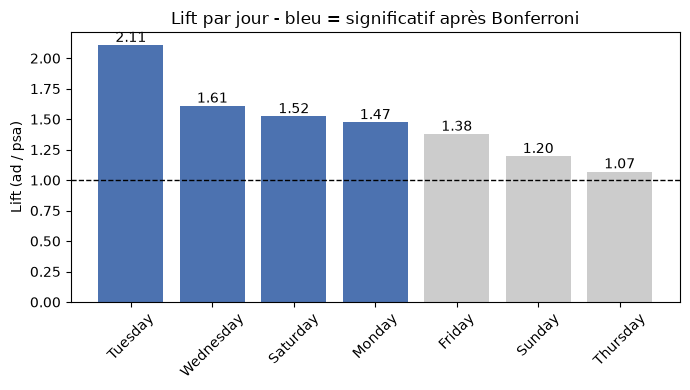

In [42]:
ordre = taux_jour.sort_values("lift_relatif", ascending=False)
significatifs = {"Tuesday", "Wednesday", "Monday", "Saturday"}
couleurs = ["#4C72B0" if j in significatifs else "#CCCCCC" for j in ordre.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ordre.index, ordre["lift_relatif"], color=couleurs)
ax.axhline(1, color="black", linestyle="--", linewidth=1)   # niveau « aucun effet »
ax.set_ylabel("Lift (ad / psa)")
ax.set_title("Lift par jour - bleu = significatif après Bonferroni")
ax.bar_label(bars, fmt="%.2f")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lift_par_jour.png", dpi=120)
plt.show()